## Imports and configuration

In [2]:
# pip install numpy pandas matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import zip_longest

In [3]:
DATA_DIR = Path("../outputs/")

SCENARIOS = {
    2000: ("norecommendation_2000.csv", "withrecommendation_2000.csv"),
    2400: ("norecommendation_2400.csv", "withrecommendation_2400.csv"),
    2800: ("norecommendation_2800.csv", "withrecommendation_2800.csv"),
}

ROAD_LENGTH_M  = 280.0   # total monitored road length
QUEUE_THRESHOLD_M = 0.0  # queue counts when q_len_m > this
ZONE_LENGTHS = {"z1": 140.0, "z2": 60.0, "z3": 80.0}

## Load data

In [4]:
def load(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["density_vpkm"]    = df["total_cars"] / ROAD_LENGTH_M * 1000
    df["z1_density_vpkm"] = df["cars_z1"]   / ZONE_LENGTHS["z1"] * 1000
    df["z2_density_vpkm"] = df["cars_z2"]   / ZONE_LENGTHS["z2"] * 1000
    df["z3_density_vpkm"] = df["cars_z3"]   / ZONE_LENGTHS["z3"] * 1000
    df["in_queue"]        = df["q_len_m"] > QUEUE_THRESHOLD_M
    return df

dfs = {}   # dfs[(n_cars, "with"/"without")]
for n_cars, (no_rec, with_rec) in SCENARIOS.items():
    dfs[(n_cars, "without")] = load(DATA_DIR / no_rec)
    dfs[(n_cars, "with")]    = load(DATA_DIR / with_rec)

print("Loaded scenarios:", list(SCENARIOS.keys()))

Loaded scenarios: [2000, 2400, 2800]


## Summary statistics table

In [5]:
def summarize(df: pd.DataFrame, label: str) -> dict:
    duration = df["sim_time"].iloc[-1] - df["sim_time"].iloc[0]
    dt = df["sim_time"].diff().median()  # typical sample interval
    queue_time = df["in_queue"].sum() * dt

    return {
        "Label":            label,
        "Samples":          len(df),
        "Duration (s)":     round(duration, 1),
        "Avg speed (m/s)":  round(df["avg_speed"].mean(), 2),
        "Avg cars":         round(df["total_cars"].mean(), 1),
        "Peak cars":        df["total_cars"].max(),
        "Avg density (v/km)":  round(df["density_vpkm"].mean(), 2),
        "Peak density (v/km)": round(df["density_vpkm"].max(), 2),
        "Avg queue (m)":    round(df["q_len_m"].mean(), 2),
        "Peak queue (m)":   round(df["q_len_m"].max(), 2),
        "Queue time (s)":   round(queue_time, 1),
        "Queue time (%)":   round(queue_time / duration * 100, 1),
        "Avg Z1 (v/km)":    round(df["z1_density_vpkm"].mean(), 2),
        "Avg Z2 (v/km)":    round(df["z2_density_vpkm"].mean(), 2),
        "Avg Z3 (v/km)":    round(df["z3_density_vpkm"].mean(), 2),
    }

rows = []
for n_cars in SCENARIOS:
    rows.append(summarize(dfs[(n_cars, "without")], f"{n_cars} cars — no rec"))
    rows.append(summarize(dfs[(n_cars, "with")],    f"{n_cars} cars — with rec"))

summary_df = pd.DataFrame(rows).set_index("Label")
summary_df

,Samples,Duration (s),Avg speed (m/s),Avg cars,Peak cars,Avg density (v/km),Peak density (v/km),Avg queue (m),Peak queue (m),Queue time (s),Queue time (%),Avg Z1 (v/km),Avg Z2 (v/km),Avg Z3 (v/km)
Label,,,,,,,,,,,,,,
2000 cars — no rec,996,995.0,12.84,20.0,42,71.56,150.00,89.49,257.62,781.0,78.5,64.84,83.92,74.05
2000 cars — with rec,2988,995.0,25.31,11.1,42,39.52,150.00,36.63,257.62,1023.0,102.8,39.40,46.96,34.15
2400 cars — no rec,1992,995.0,31.61,6.7,29,23.82,103.57,11.83,203.71,255.0,25.6,27.69,28.96,13.20
2400 cars — with rec,996,995.0,31.54,6.6,26,23.50,92.86,10.20,203.71,121.0,12.2,26.68,28.48,14.21
2800 cars — no rec,996,995.0,8.36,26.7,47,95.23,167.86,106.73,251.57,806.0,81.0,72.40,116.35,119.34
2800 cars — with rec,996,995.0,8.36,26.7,47,95.23,167.86,106.73,251.57,806.0,81.0,72.40,116.35,119.34


## Delta table (explicit difference)

In [6]:
delta_rows = []
for n_cars in SCENARIOS:
    wo = summarize(dfs[(n_cars, "without")], "without")
    wi = summarize(dfs[(n_cars, "with")],    "with")
    numeric_cols = [k for k in wo if k not in ("Label", "Samples", "Duration (s)")]
    delta = {"Scenario": f"{n_cars} cars"}
    for col in numeric_cols:
        delta[f"Δ {col}"] = round(wi[col] - wo[col], 3)
    delta_rows.append(delta)

delta_df = pd.DataFrame(delta_rows).set_index("Scenario")
delta_df.style.map(lambda v: "color: green" if v < 0 else "color: red", subset=[c for c in delta_df.columns if "queue" in c.lower() or "density" in c.lower()])

,Δ Avg speed (m/s),Δ Avg cars,Δ Peak cars,Δ Avg density (v/km),Δ Peak density (v/km),Δ Avg queue (m),Δ Peak queue (m),Δ Queue time (s),Δ Queue time (%),Δ Avg Z1 (v/km),Δ Avg Z2 (v/km),Δ Avg Z3 (v/km)
Scenario,,,,,,,,,,,,
2000 cars,12.470000,-8.900000,0,-32.040000,0.000000,-52.860000,0.000000,242.000000,24.300000,-25.440000,-36.960000,-39.900000
2400 cars,-0.070000,-0.100000,-3,-0.320000,-10.710000,-1.630000,0.000000,-134.000000,-13.400000,-1.010000,-0.480000,1.010000
2800 cars,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Time-series plots per scenario

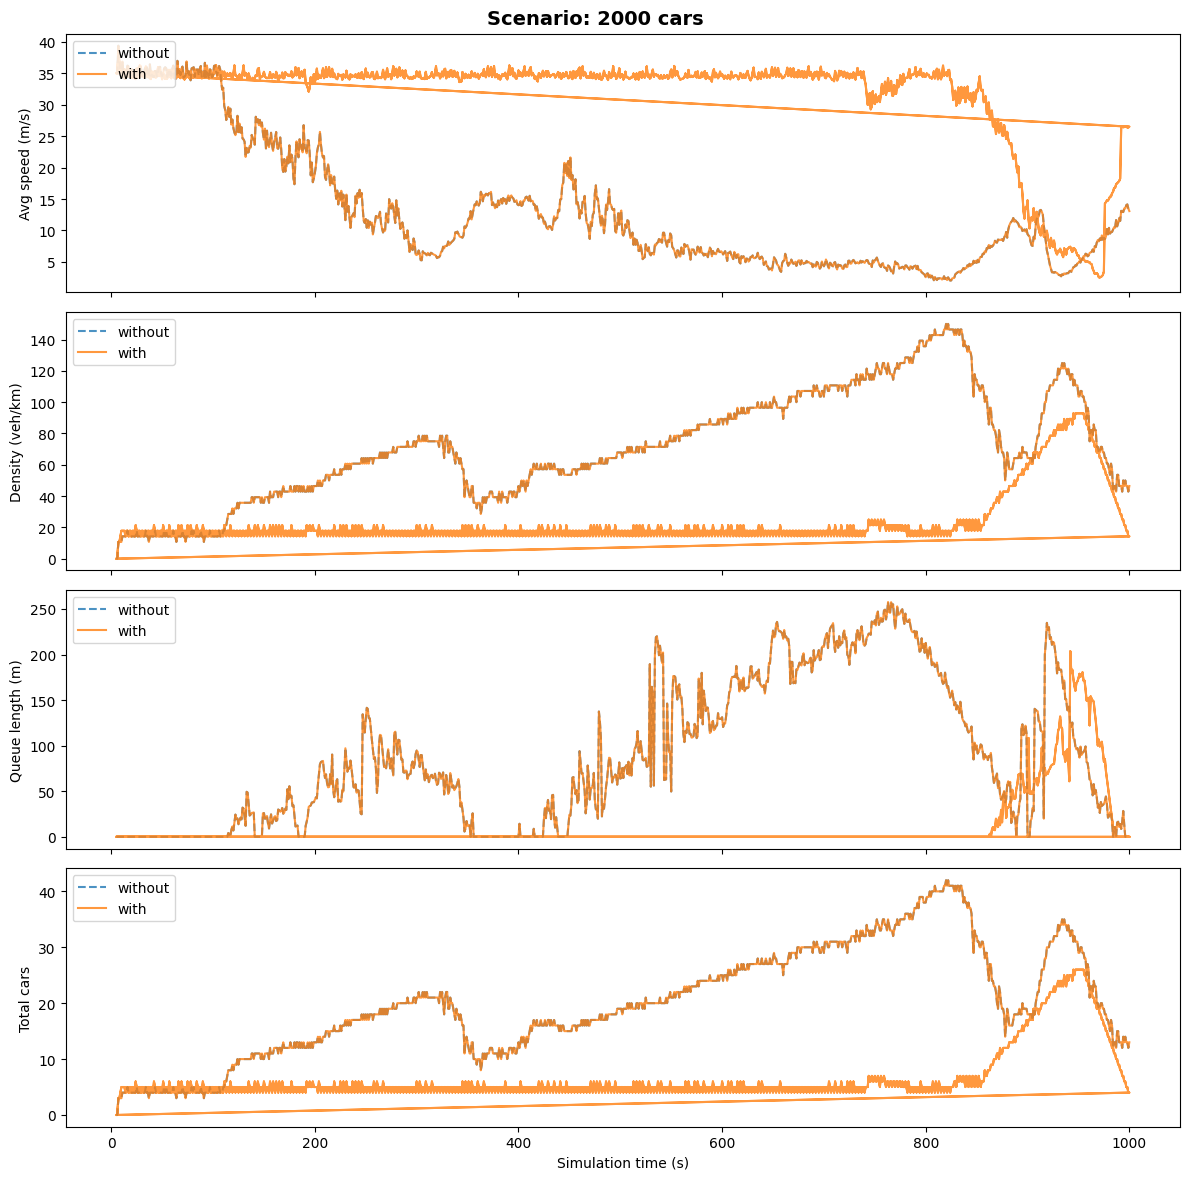

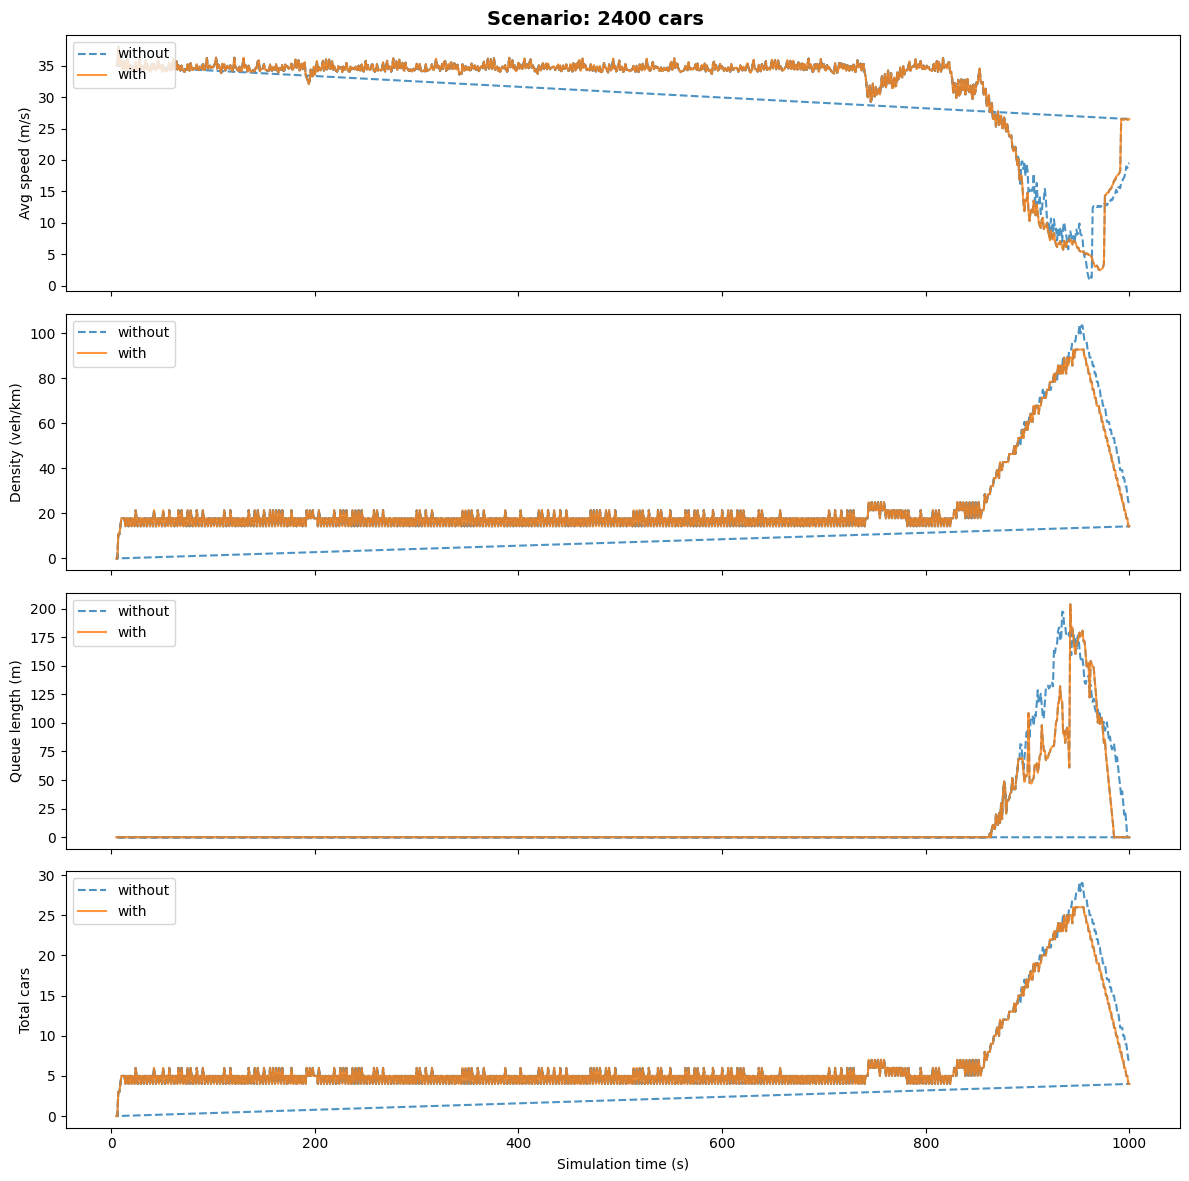

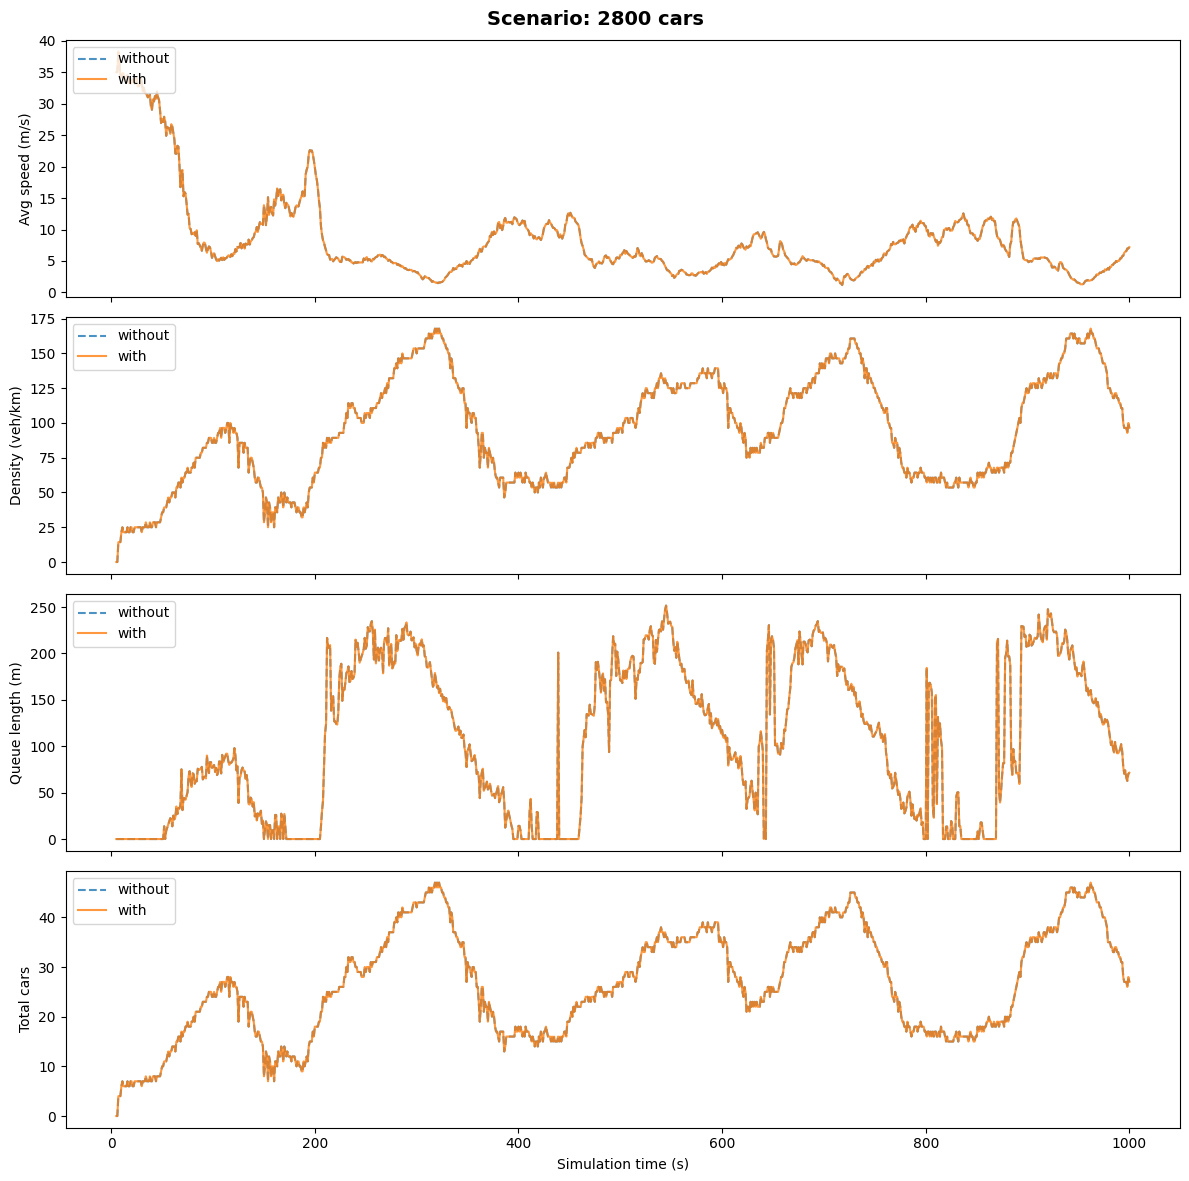

In [7]:
METRICS = {
    "avg_speed":      "Avg speed (m/s)",
    "density_vpkm":   "Density (veh/km)",
    "q_len_m":        "Queue length (m)",
    "total_cars":     "Total cars",
}

for n_cars in SCENARIOS:
    fig, axes = plt.subplots(len(METRICS), 1, figsize=(12, 3 * len(METRICS)), sharex=True)
    fig.suptitle(f"Scenario: {n_cars} cars", fontsize=14, fontweight="bold")

    for ax, (col, ylabel) in zip(axes, METRICS.items()):
        for label, style in [("without", "--"), ("with", "-")]:
            df = dfs[(n_cars, label)]
            ax.plot(df["sim_time"], df[col], linestyle=style, label=label, alpha=0.8)
        ax.set_ylabel(ylabel)
        ax.legend(loc="upper left")

    axes[-1].set_xlabel("Simulation time (s)")
    plt.tight_layout()
    plt.show()

## Cross-scenario comparison bar chart

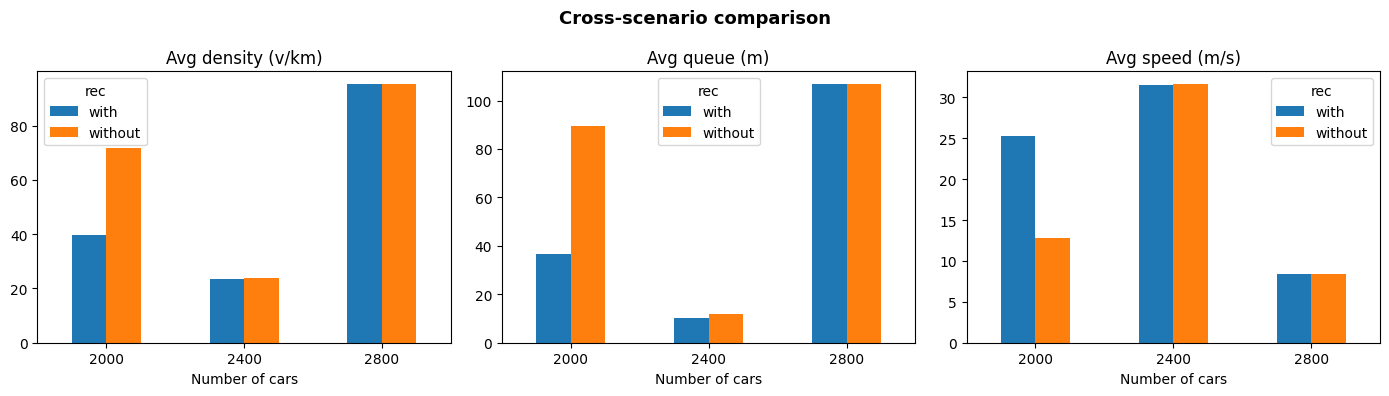

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
metrics = ["Avg density (v/km)", "Avg queue (m)", "Avg speed (m/s)"]

for ax, metric in zip(axes, metrics):
    plot_data = summary_df[metric].reset_index()
    plot_data["n_cars"] = plot_data["Label"].str.extract(r"(\d+) cars").astype(int)
    plot_data["rec"]    = plot_data["Label"].str.contains("with rec").map({True: "with", False: "without"})
    pivot = plot_data.pivot(index="n_cars", columns="rec", values=metric)
    pivot.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(metric)
    ax.set_xlabel("Number of cars")

plt.suptitle("Cross-scenario comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()